## Step 1: Verify Environment and Import Libraries
Check GPU is available in Colab (Runtime → GPU).
Importing required libraries

In [32]:
# importing required libraries
import numpy as np
import pandas as pd
import torch

In [33]:
# checking for gpu available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## Step 2: Get the Dataset
Download Kaggle "chest-xray-pneumonia" dataset and unzip.

In [34]:
import os

!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

mv: cannot stat 'kaggle.json': No such file or directory


In [35]:
# downloading the dataset
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
chest-xray-pneumonia.zip: Skipping, found more recently modified local copy (use --force to force download)


In [36]:
# unzip the downloaded file
!unzip -q chest-xray-pneumonia.zip

replace chest_xray/__MACOSX/._chest_xray? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


## Step 3: Confirm Correct Dataset Path
The zip extracted with a nested/duplicate folder structure. Before building dataloaders, inspect `/content/chest_xray` to find exactly where train/test/val actually live, so we point ImageFolder at the right path.

In [37]:
data_path = "/content/chest_xray/chest_xray"
# finding the folder structure there
os.listdir(data_path)

['val', 'train', 'test', '.DS_Store']

## Step 4: Build Dataloaders
Load train/test/val from `/content/chest_xray/chest_xray/` using ImageFolder. Use augmentation (flip/rotation) + normalization for train; resize + normalization only for test/val. Wrap in DataLoaders (batch size 32, shuffle train only). Confirm `dataset.classes` order and dataset sizes match expected counts.

In [38]:
# using ImageFolder
# can handle this type of structure
from torchvision import datasets,transforms
from torch.utils.data import DataLoader

In [39]:
# data path
data_path = "/content/chest_xray/chest_xray"

In [40]:
# transformation for images
train_transform = transforms.Compose([  # for training
    transforms.Resize((224,224)),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([  # for test and val
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# loading the dataset using ImageFolder
train_dataset = datasets.ImageFolder(data_path + "/train", transform=train_transform)
val_dataset = datasets.ImageFolder(data_path + "/val", transform=val_transform)
test_dataset = datasets.ImageFolder(data_path + "/test", transform=val_transform)

In [41]:
# creating data loaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [42]:
# classes in training dataset
print(train_dataset.classes)

['NORMAL', 'PNEUMONIA']


In [43]:
# length of all three
print(len(train_dataset))
print(len(test_dataset))
print(len(val_dataset))

5216
624
16


## Step 5: Fix the Validation Set
Issue: the provided `val` folder has only 16 images - too small to be useful for monitoring training.
Fix: split the `train` set into a proper train/val split ourselves, making sure augmentation is applied to train only, not val.

In [44]:
# fixing the issue
# this is the proper version
# creating two instances of ImageFolder
train_dataset_aug = datasets.ImageFolder(data_path + "/train", transform=train_transform)
train_dataset_clean = datasets.ImageFolder(data_path + "/train", transform=val_transform)

In [45]:
# split indices, then apply Subset
from torch.utils.data import Subset
import numpy as np

n = len(train_dataset_aug)
indices = np.arange(n)

np.random.seed(42)
np.random.shuffle(indices)

split = int(0.85 * n)
train_indices = indices[:split]
val_indices = indices[split:]

train_dataset = Subset(train_dataset_aug, train_indices)
val_dataset = Subset(train_dataset_clean, val_indices)

# rebuilding loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(len(train_dataset), len(val_dataset))

4433 783


## Step 5: Build the Model
Using a pretrained resnet18 and changing the last layer to output 2 classes instead of 1000 (normal vs pneumonia). Moving model to gpu. Using CrossEntropyLoss and Adam optimizer with lr=1e-4. Also freezing the early layers and only training the last block + final layer so it trains faster and doesn't overfit as much.

In [47]:
import torch.nn as nn
from torchvision import models

# loading the pre-trained model resnet18
# weights --> default
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# frezzing everything first
for param in model.parameters():
  param.requires_grad = False

# only unfreezing layer 4
# this is for faster training
for param in model.layer4.parameters():
  param.requires_grad = True

# modifying the final fully connected layer
# num of classes for chest_xray is two
in_features = model.fc.in_features

# replacing the final layer
model.fc = nn.Linear(in_features,2)
model = model.to(device)

print("Model Setup completed..")
print(model.fc)

Model Setup completed..
Linear(in_features=512, out_features=2, bias=True)


In [48]:
# defining loss function
# defining optimizer
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
)

## Step 6: Training Loop
Writing a loop to train the model for a few epochs. For each epoch, looping through train_loader, doing forward pass, computing loss, backprop, optimizer step. Also running validation after each epoch to check val loss/accuracy and see if the model is actually learning. Saving the best model based on val accuracy.

In [49]:
# Step 6: Training loop with history tracking

num_epochs = 10
best_val_acc = 0.0

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(num_epochs):

    # training phase
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    # validation phase
    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_running_loss / val_total
    val_acc = val_correct / val_total

    # recording history
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # saving best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")
        print(f"  → New best model saved (val_acc={val_acc:.4f})")

print("Training complete. Best val accuracy:", best_val_acc)

Epoch 1/10 | Train Loss: 0.1145 Acc: 0.9533 | Val Loss: 0.0626 Acc: 0.9783
  → New best model saved (val_acc=0.9783)
Epoch 2/10 | Train Loss: 0.0644 Acc: 0.9772 | Val Loss: 0.0541 Acc: 0.9770
Epoch 3/10 | Train Loss: 0.0362 Acc: 0.9876 | Val Loss: 0.0474 Acc: 0.9821
  → New best model saved (val_acc=0.9821)
Epoch 4/10 | Train Loss: 0.0360 Acc: 0.9874 | Val Loss: 0.0436 Acc: 0.9808
Epoch 5/10 | Train Loss: 0.0327 Acc: 0.9874 | Val Loss: 0.0492 Acc: 0.9808
Epoch 6/10 | Train Loss: 0.0245 Acc: 0.9901 | Val Loss: 0.0380 Acc: 0.9847
  → New best model saved (val_acc=0.9847)
Epoch 7/10 | Train Loss: 0.0213 Acc: 0.9903 | Val Loss: 0.0616 Acc: 0.9847
Epoch 8/10 | Train Loss: 0.0259 Acc: 0.9921 | Val Loss: 0.0398 Acc: 0.9834
Epoch 9/10 | Train Loss: 0.0142 Acc: 0.9957 | Val Loss: 0.0340 Acc: 0.9898
  → New best model saved (val_acc=0.9898)
Epoch 10/10 | Train Loss: 0.0124 Acc: 0.9957 | Val Loss: 0.0308 Acc: 0.9885
Training complete. Best val accuracy: 0.9897828863346104


## Step 7: Evaluate on Test Set
Loading the best saved model and running it on the untouched test set to get real performance numbers - accuracy, precision, recall, F1, and a confusion matrix. This matters more than val accuracy since test set was never touched during training/tuning.

              precision    recall  f1-score   support

      NORMAL       0.98      0.53      0.69       234
   PNEUMONIA       0.78      0.99      0.87       390

    accuracy                           0.82       624
   macro avg       0.88      0.76      0.78       624
weighted avg       0.85      0.82      0.80       624



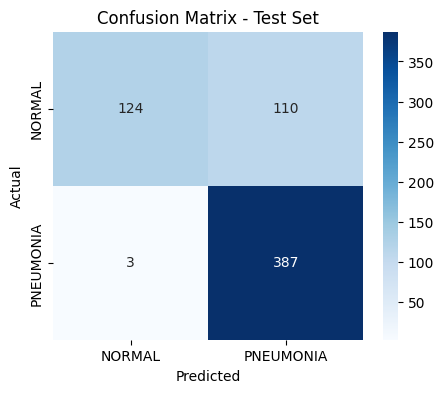

In [50]:
# eval on test set
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# reloading architecture and load best weights
eval_model = models.resnet18(weights=None)
eval_model.fc = nn.Linear(eval_model.fc.in_features, 2)
eval_model.load_state_dict(torch.load("best_model.pth"))
eval_model = eval_model.to(device)
eval_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = eval_model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# classification report
class_names = ["NORMAL", "PNEUMONIA"]
print(classification_report(all_labels, all_preds, target_names=class_names))

# confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Test Set")
plt.show()

## Step 8: Grad-CAM on Correct Pneumonia Predictions
Picking a few test images the model correctly classified as PNEUMONIA, generating Grad-CAM heatmaps, and overlaying them on the original X-rays to check whether the model is actually focusing on lung regions (real pathology signal) rather than irrelevant areas like borders or text markers.

In [51]:
# installing grad cam
!pip install grad-cam -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 71.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


Found 387 correct pneumonia predictions


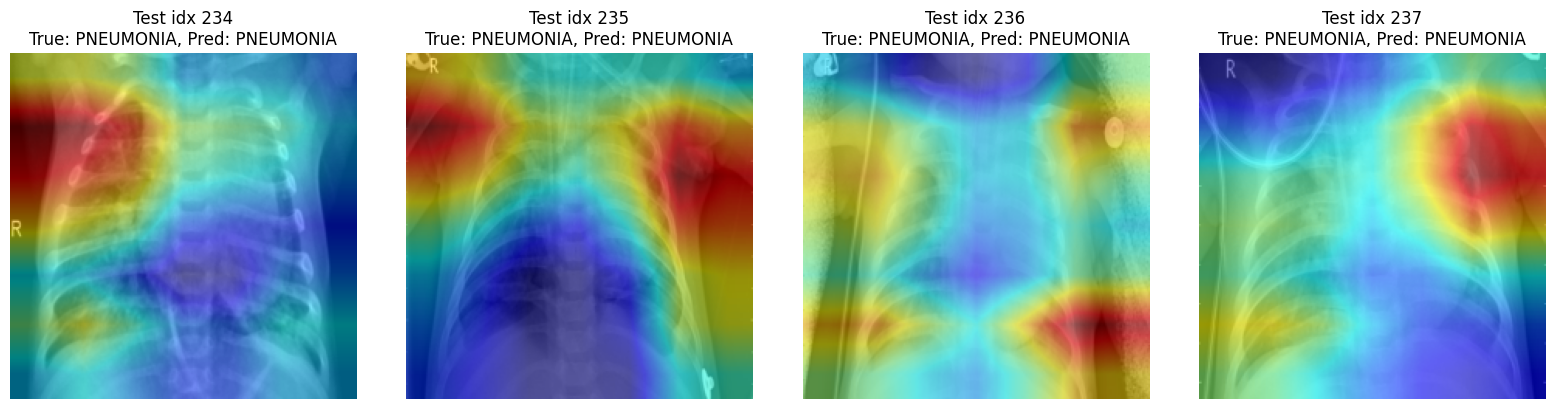

In [52]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# target layer for ResNet18 - last conv block
target_layers = [eval_model.layer4[-1]]

cam = GradCAM(model=eval_model, target_layers=target_layers)

# finding test images that are correctly predicted as PNEUMONIA (label=1)
correct_pneumonia_indices = []
for i, (pred, label) in enumerate(zip(all_preds, all_labels)):
    if pred == 1 and label == 1:
        correct_pneumonia_indices.append(i)

print(f"Found {len(correct_pneumonia_indices)} correct pneumonia predictions")

# picking a handful to visualize
num_to_show = 4
selected_indices = correct_pneumonia_indices[:num_to_show]

# helper to unnormalize image tensor for display
def unnormalize(img_tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img_tensor.cpu().numpy().transpose(1, 2, 0)
    img = std * img + mean
    img = np.clip(img, 0, 1)
    return img

# rebuilding test_dataset without shuffling to index directly
fig, axes = plt.subplots(1, num_to_show, figsize=(4 * num_to_show, 4))

for ax, idx in zip(axes, selected_indices):
    image_tensor, label = test_dataset[idx]
    input_tensor = image_tensor.unsqueeze(0).to(device)

    targets = [ClassifierOutputTarget(1)]  # PNEUMONIA class
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
    grayscale_cam = grayscale_cam[0, :]

    rgb_img = unnormalize(image_tensor)
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    ax.imshow(visualization)
    ax.set_title(f"Test idx {idx}\nTrue: PNEUMONIA, Pred: PNEUMONIA")
    ax.axis("off")

plt.tight_layout()
plt.show()